# Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
# We can override the default matplotlib styles with those of Seaborn
sns.set()

# Load the data from a .csv in the same folder. Since we will do some preprocessing, the variable is not called 'data' just yet!

In [4]:
raw_data = pd.read_csv('dummies.csv')

In [5]:
raw_data

,SAT,GPA,Attendance
0,1714,2.40,No
1,1664,2.52,No
2,1760,2.54,No
3,1685,2.74,No
4,1693,2.83,No
...,...,...,...
79,1936,3.71,Yes
80,1810,3.71,Yes
81,1987,3.73,No
82,1962,3.76,Yes


# Map all 'No' entries with 0, and all 'Yes' entries with 1. Put that in a new variable called 'data'
# Note data is a copy of raw_data, because of how pointers in Python work

In [6]:
data = raw_data.copy()
data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})
# Let's see what's inside
data

,SAT,GPA,Attendance
0,1714,2.40,0
1,1664,2.52,0
2,1760,2.54,0
3,1685,2.74,0
4,1693,2.83,0
...,...,...,...
79,1936,3.71,1
80,1810,3.71,1
81,1987,3.73,0
82,1962,3.76,1


# This method gives us very nice descriptive statistics.

In [7]:
data.describe()

,SAT,GPA,Attendance
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,0.464286
std,104.530661,0.271617,0.501718
min,1634.000000,2.400000,0.000000
25%,1772.000000,3.190000,0.000000
50%,1846.000000,3.380000,0.000000
75%,1934.000000,3.502500,1.000000
max,2050.000000,3.810000,1.000000


# Following the regression equation, our dependent variable (y) is the GPA

In [8]:
y = data['GPA']
X1 = data[['SAT', 'Attendance']]

In [9]:
x = sm.add_constant(X1)
results = sm.OLS(y, x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           2.19e-15
Time:                        16:14:00   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   1.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

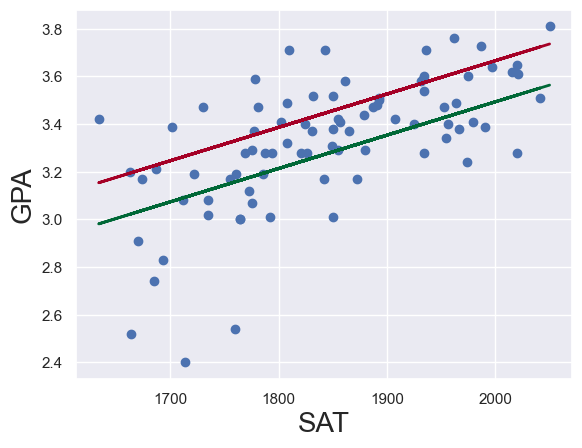

In [11]:
plt.scatter(X1['SAT'], y)
yhat_no = 0.6939 + 0.0014 * data['SAT'] # (const + + SAT * data['DAT']) where Attendance = 0
yhat_yes = 0.8665 + 0.0014 * data['SAT'] # ((const + Attendance) + SAT * data['DAT']) where Attendance = 1
fig = plt.plot(data['SAT'], yhat_no, lw=2, c='#006837')
fig = plt.plot(data['SAT'], yhat_yes, lw=2, c='#a50026')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()

# Make prediction based on regression we create

In [12]:
x

,const,SAT,Attendance
0,1.0,1714,0
1,1.0,1664,0
2,1.0,1760,0
3,1.0,1685,0
4,1.0,1693,0
...,...,...,...
79,1.0,1936,1
80,1.0,1810,1
81,1.0,1987,0
82,1.0,1962,1


In [13]:
new_data = pd.DataFrame({'const': 1, 'SAT': [1700, 1800], 'Attendance': [1, 0]})
new_data = new_data[['const', 'SAT', 'Attendance']]
new_data

,const,SAT,Attendance
0,1,1700,1
1,1,1800,0


In [16]:
new_data.rename(index={0: 'Bob', 1: 'Alice'}, inplace=True)
new_data

,const,SAT,Attendance
Bob,1,1700,1
Alice,1,1800,0


In [17]:
predictions = results.predict(new_data)
predictions

Bob      3.246157
Alice    3.163493
dtype: float64

In [18]:
prediction_df = pd.DataFrame(predictions, columns=['Predicted GPA'])
joined = new_data.join(prediction_df)
joined

,const,SAT,Attendance,Predicted GPA
Bob,1,1700,1,3.246157
Alice,1,1800,0,3.163493
